In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, LinearSegmentedColormap
from matplotlib.ticker import LogFormatterMathtext
import matplotlib.ticker as ticker
from scipy.ndimage import gaussian_filter
import numpy as np
import pandas as pd
import dask
import zarr
import xarray as xr

In [2]:
llc_path = '/orcd/data/abodner/002/cody/LLC_patch/LLC4320_face1_i2880-3600_j720-1440.zarr'
llc_patch_full = xr.open_dataset(llc_path, consolidated=True)

emulator_path = '/orcd/data/abodner/002/cody/inference_patch/predictions/2026-03-26-eval:samudra_llc:epoch1_oct2012_patchloc=i(2880,3600)-j(720,1440)/predictions_4d.zarr'
emulator_patch_full = xr.open_dataset(emulator_path, consolidated=True)
#emulator_patch_full = xr.open_dataset(llc_path, consolidated=True)

In [3]:
extent = 1
llc_patch = llc_patch_full.isel(time=slice(9216, 9216 + extent))
emulator_patch = emulator_patch_full.isel(time=slice(0, extent))#(9216, 9216 + extent))#(0, extent))

In [4]:
# Rename lat/lon to j/i
emulator_patch = emulator_patch.rename({'lat': 'j', 'lon': 'i'})

# Copy over coordinates from llc_patch
emulator_patch['XC'] = llc_patch['XC']
emulator_patch['YC'] = llc_patch['YC']
emulator_patch['rA'] = llc_patch['rA']
emulator_patch['Z'] = llc_patch['Z']

In [5]:
omega = 7.2921e-5
f_0_llc = np.abs(2 * omega * np.sin(np.deg2rad(llc_patch['YC'].values)))

# Get grid spacing from rA (cell area) - approximate dx, dy
dx = np.sqrt(llc_patch['rA'].values)  # (j, i) in meters
dy = dx.copy()  
U = llc_patch['U'].values
V = llc_patch['V'].values

dvdx = (np.roll(V, -1, axis=3) - np.roll(V, 1, axis=3)) / (2 * dx[np.newaxis, np.newaxis, :, :])
dudy = (np.roll(U, -1, axis=2) - np.roll(U, 1, axis=2)) / (2 * dy[np.newaxis, np.newaxis, :, :])

vort_llc = dvdx - dudy

vort_llc_normalized = vort_llc / f_0_llc[np.newaxis, np.newaxis, :, :]

llc_patch['vorticity'] = (('time', 'k', 'j', 'i'), vort_llc_normalized)



In [6]:
omega = 7.2921e-5
f_0_emulator = np.abs(2 * omega * np.sin(np.deg2rad(emulator_patch['YC'].values)))

# Get grid spacing from rA (cell area) - approximate dx, dy
dx = np.sqrt(emulator_patch['rA'].values)  # (j, i) in meters
dy = dx.copy()  
U = emulator_patch['U'].values
V = emulator_patch['V'].values

dvdx = (np.roll(V, -1, axis=3) - np.roll(V, 1, axis=3)) / (2 * dx[np.newaxis, np.newaxis, :, :])
dudy = (np.roll(U, -1, axis=2) - np.roll(U, 1, axis=2)) / (2 * dy[np.newaxis, np.newaxis, :, :])

vort_emulator = dvdx - dudy

vort_emulator_normalized = vort_emulator / f_0_emulator[np.newaxis, np.newaxis, :, :]

emulator_patch['vorticity'] = (('time', 'k', 'j', 'i'), vort_emulator_normalized)

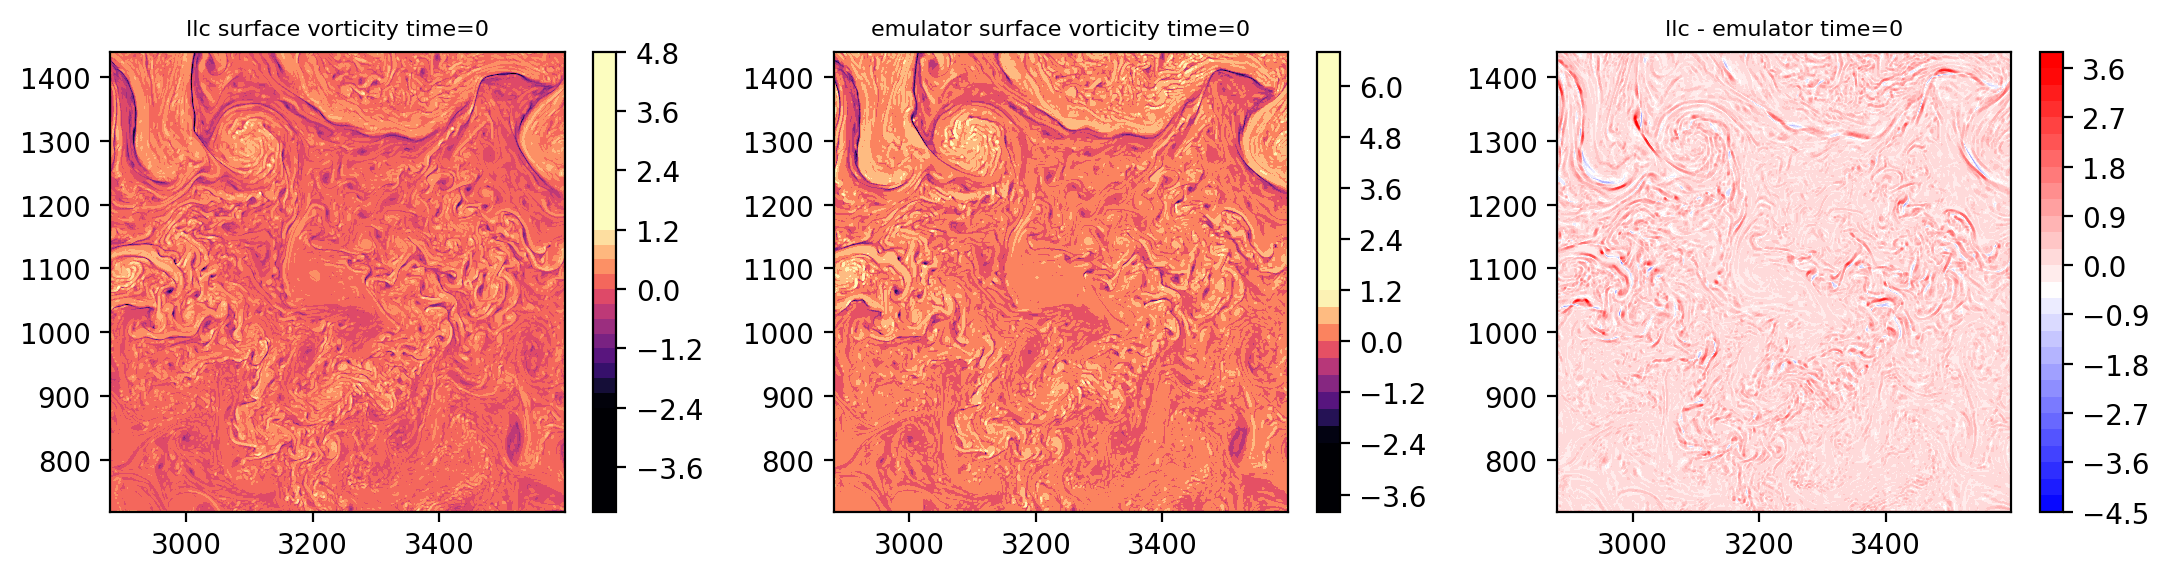

In [12]:
llc_vis = llc_patch.isel(time=0,k=0).vorticity
emulator_vis = emulator_patch.isel(time=0,k=0).vorticity

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(11, 3), dpi=200)

# LLC
vmin_llc = float(llc_vis.quantile(0.001))
vmax_llc = float(llc_vis.quantile(0.999))
cf1 = ax1.contourf(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
    llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis, \
        cmap="magma", vmin=vmin_llc, vmax=vmax_llc, levels=30)
plt.colorbar(cf1, ax=ax1)
ax1.set_title('llc surface vorticity time=0', fontsize=8)

# Emulator
vmin_emu = float(emulator_vis.quantile(0.001))
vmax_emu = float(emulator_vis.quantile(0.999))
cf2 = ax2.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
        cmap="magma", vmin=vmin_emu, vmax=vmax_emu, levels=30)
plt.colorbar(cf2, ax=ax2)
ax2.set_title('emulator surface vorticity time=0', fontsize=8)

# Difference
diff = llc_vis - emulator_vis
vmin_diff = -4.5 # float(diff.quantile(0.001))
vmax_diff = 3.6 # float(diff.quantile(0.999))
cf3 = ax3.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), diff, \
        cmap="bwr", vmin=vmin_diff, vmax=vmax_diff, levels=30)
plt.colorbar(cf3, ax=ax3)
ax3.set_title('llc - emulator time=0', fontsize=8)

plt.tight_layout()
plt.show()

In [13]:

omega = 7.2921e-5
f_0_llc = np.abs(2 * omega * np.sin(np.deg2rad(llc_patch['YC'].values)))

dx = np.sqrt(llc_patch['rA'].values)  # (j, i) in meters
dy = dx.copy()

U = llc_patch['U'].values
V = llc_patch['V'].values

u_x_llc = (np.roll(U, -1, axis=3) - np.roll(U, 1, axis=3)) / (2 * dx[np.newaxis, np.newaxis, :, :])
u_y_llc = (np.roll(U, -1, axis=2) - np.roll(U, 1, axis=2)) / (2 * dy[np.newaxis, np.newaxis, :, :])
v_x_llc = (np.roll(V, -1, axis=3) - np.roll(V, 1, axis=3)) / (2 * dx[np.newaxis, np.newaxis, :, :])
v_y_llc = (np.roll(V, -1, axis=2) - np.roll(V, 1, axis=2)) / (2 * dy[np.newaxis, np.newaxis, :, :])

sigma_n_llc = u_x_llc - v_y_llc
sigma_s_llc = v_x_llc + u_y_llc
sigma_llc = np.sqrt(sigma_n_llc**2 + sigma_s_llc**2)

sigma_llc_normalized = sigma_llc / f_0_llc[np.newaxis, np.newaxis, :, :]

llc_patch['strain'] = (('time', 'k', 'j', 'i'), sigma_llc_normalized)


In [14]:
omega = 7.2921e-5
f_0_emulator= np.abs(2 * omega * np.sin(np.deg2rad(emulator_patch['YC'].values)))

dx = np.sqrt(emulator_patch['rA'].values)  # (j, i) in meters
dy = dx.copy()

U = emulator_patch['U'].values
V = emulator_patch['V'].values

u_x_emulator = (np.roll(U, -1, axis=3) - np.roll(U, 1, axis=3)) / (2 * dx[np.newaxis, np.newaxis, :, :])
u_y_emulator = (np.roll(U, -1, axis=2) - np.roll(U, 1, axis=2)) / (2 * dy[np.newaxis, np.newaxis, :, :])
v_x_emulator = (np.roll(V, -1, axis=3) - np.roll(V, 1, axis=3)) / (2 * dx[np.newaxis, np.newaxis, :, :])
v_y_emulator = (np.roll(V, -1, axis=2) - np.roll(V, 1, axis=2)) / (2 * dy[np.newaxis, np.newaxis, :, :])

sigma_n_emulator = u_x_emulator - v_y_emulator
sigma_s_emulator = v_x_emulator + u_y_emulator
sigma_emulator = np.sqrt(sigma_n_emulator**2 + sigma_s_emulator**2)

sigma_emulator_normalized = sigma_emulator / f_0_emulator[np.newaxis, np.newaxis, :, :]

emulator_patch['strain'] = (('time', 'k', 'j', 'i'), sigma_emulator_normalized)

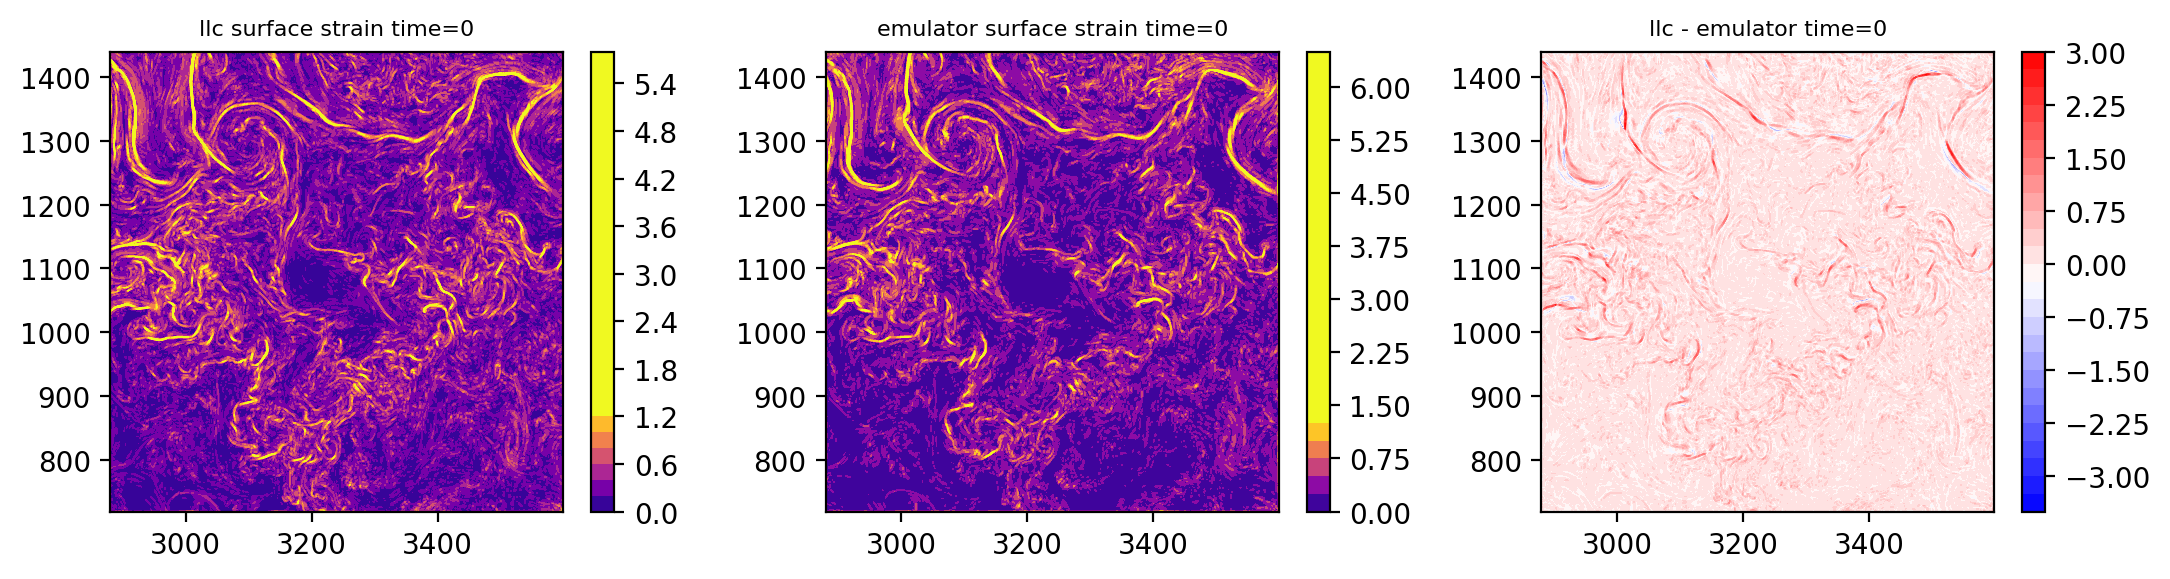

In [ ]:
llc_vis = llc_patch.isel(time=0,k=0).strain
emulator_vis = emulator_patch.isel(time=0,k=0).strain

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(11, 3), dpi=200)
vmin_llc = 0
vmax_llc = float(llc_vis.quantile(0.99))
cf1 = ax1.contourf(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
    llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis, \
        cmap="plasma",vmin=vmin_llc,vmax=vmax_llc, levels = 30)
plt.colorbar(cf1, ax=ax1)
ax1.set_title('llc surface strain time=0', fontsize=8)
vmin_emulator = 0
vmax_emulator = float(emulator_vis.quantile(0.99))
cf2 = ax2.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
        cmap="plasma",vmin=vmin_emulator,vmax=vmax_emulator, levels = 30)
plt.colorbar(cf2, ax=ax2)
ax2.set_title('emulator surface strain time=0', fontsize=8)

cf3 = ax3.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), llc_vis - emulator_vis, \
        cmap="bwr", levels = 30)
plt.colorbar(cf3, ax=ax3)
ax3.set_title('llc - emulator time=0', fontsize=8)

plt.tight_layout()
plt.show()

In [21]:
# LLC Patch
Theta_llc = llc_patch['Theta'].values

dx = np.sqrt(llc_patch['rA'].values)  # (j, i) in meters
dy = dx.copy()

dT_di_llc = (np.roll(Theta_llc, -1, axis=3) - np.roll(Theta_llc, 1, axis=3)) / (2 * dx[np.newaxis, np.newaxis, :, :])
dT_dj_llc = (np.roll(Theta_llc, -1, axis=2) - np.roll(Theta_llc, 1, axis=2)) / (2 * dy[np.newaxis, np.newaxis, :, :])

# Gradient magnitude |∇T| in K/m
grad_T_llc = np.sqrt(dT_di_llc**2 + dT_dj_llc**2)

llc_patch['grad_T'] = (('time', 'k', 'j', 'i'), grad_T_llc)

# Emulator Patch
Theta_emulator = emulator_patch['Theta'].values

dx = np.sqrt(emulator_patch['rA'].values)  # (j, i) in meters
dy = dx.copy()

dT_di_emulator = (np.roll(Theta_emulator, -1, axis=3) - np.roll(Theta_emulator, 1, axis=3)) / (2 * dx[np.newaxis, np.newaxis, :, :])
dT_dj_emulator = (np.roll(Theta_emulator, -1, axis=2) - np.roll(Theta_emulator, 1, axis=2)) / (2 * dy[np.newaxis, np.newaxis, :, :])

# Gradient magnitude |∇T| in K/m
grad_T_emulator = np.sqrt(dT_di_emulator**2 + dT_dj_emulator**2)

emulator_patch['grad_T'] = (('time', 'k', 'j', 'i'), grad_T_emulator)

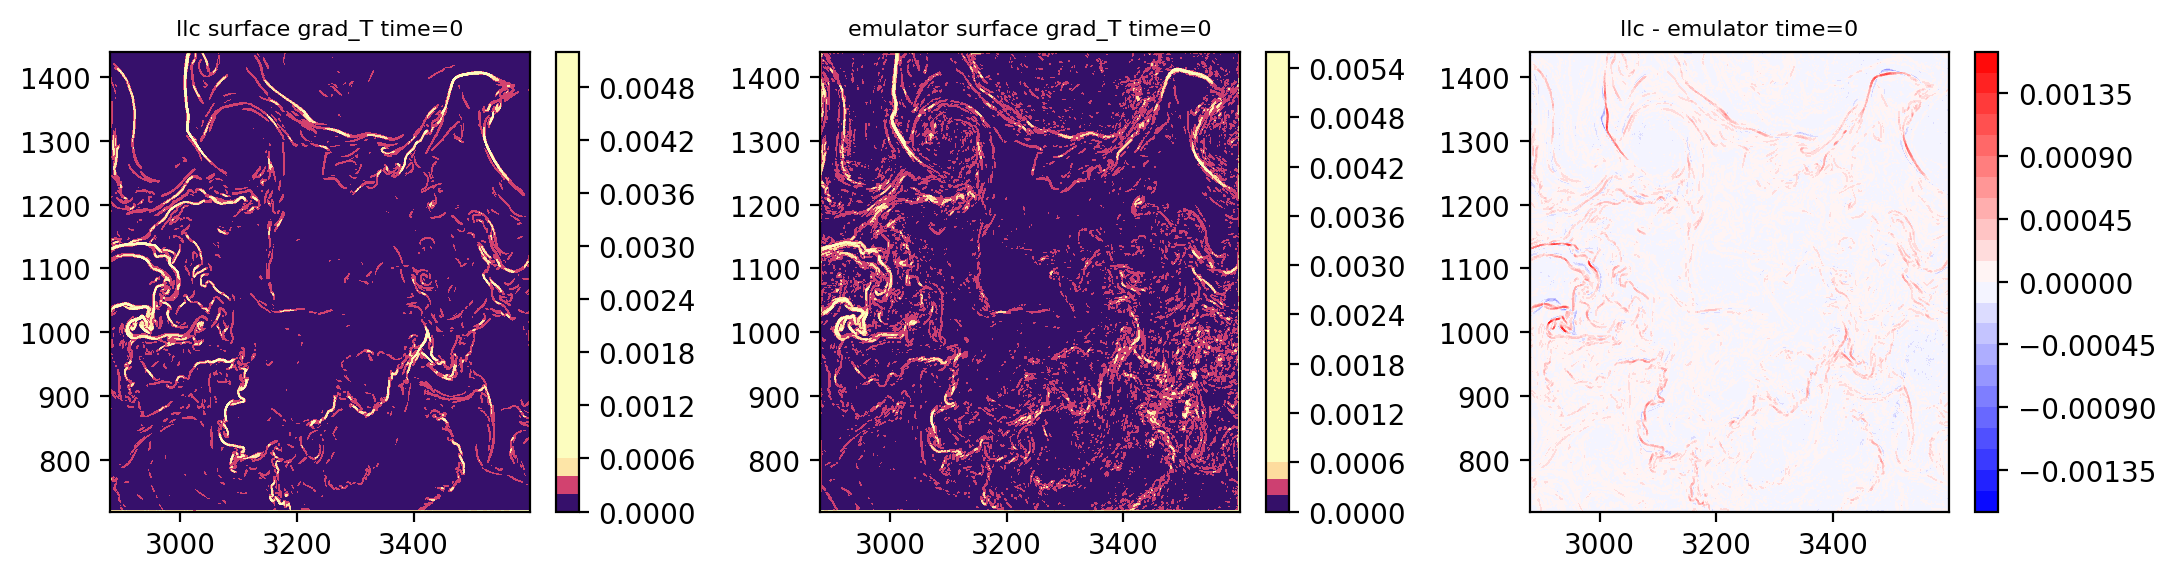

In [30]:
llc_vis = llc_patch.isel(time=0,k=0).grad_T
emulator_vis = emulator_patch.isel(time=0,k=0).grad_T

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(11, 3), dpi=200)

# LLC
vmin_llc = 0
vmax_llc = float(llc_vis.quantile(0.99))
cf1 = ax1.contourf(llc_vis.coords.get('i', np.arange(llc_vis.shape[-1])), \
    llc_vis.coords.get('j', np.arange(llc_vis.shape[-2])), llc_vis, \
        cmap="magma", vmin=vmin_llc, vmax=vmax_llc, levels=30)
plt.colorbar(cf1, ax=ax1)
ax1.set_title('llc surface grad_T time=0', fontsize=8)

# Emulator
vmin_emu = 0
vmax_emu = float(emulator_vis.quantile(0.99))
cf2 = ax2.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), emulator_vis, \
        cmap="magma", vmin=vmin_emu, vmax=vmax_emu, levels=30)
plt.colorbar(cf2, ax=ax2)
ax2.set_title('emulator surface grad_T time=0', fontsize=8)

# Difference
diff = llc_vis - emulator_vis
vmin_diff = -4.5 # float(diff.quantile(0.001))
vmax_diff = 3.6 # float(diff.quantile(0.999))
cf3 = ax3.contourf(emulator_vis.coords.get('i', np.arange(emulator_vis.shape[-1])), \
    emulator_vis.coords.get('j', np.arange(emulator_vis.shape[-2])), diff, \
        cmap="bwr", levels=30)
plt.colorbar(cf3, ax=ax3)
ax3.set_title('llc - emulator time=0', fontsize=8)

plt.tight_layout()

In [31]:
vort_hist_llc = llc_patch.vorticity.stack(vals=['time','i','j']).values
vort_hist_emulator = emulator_patch.vorticity.stack(vals=['time','i','j']).values

strain_hist_llc = llc_patch.strain.stack(vals=['time','i','j']).values
strain_hist_emulator = emulator_patch.strain.stack(vals=['time','i','j']).values

grad_T_hist_llc = llc_patch.grad_T.stack(vals=['time','i','j']).values
grad_T_hist_emulator = emulator_patch.grad_T.stack(vals=['time','i','j']).values

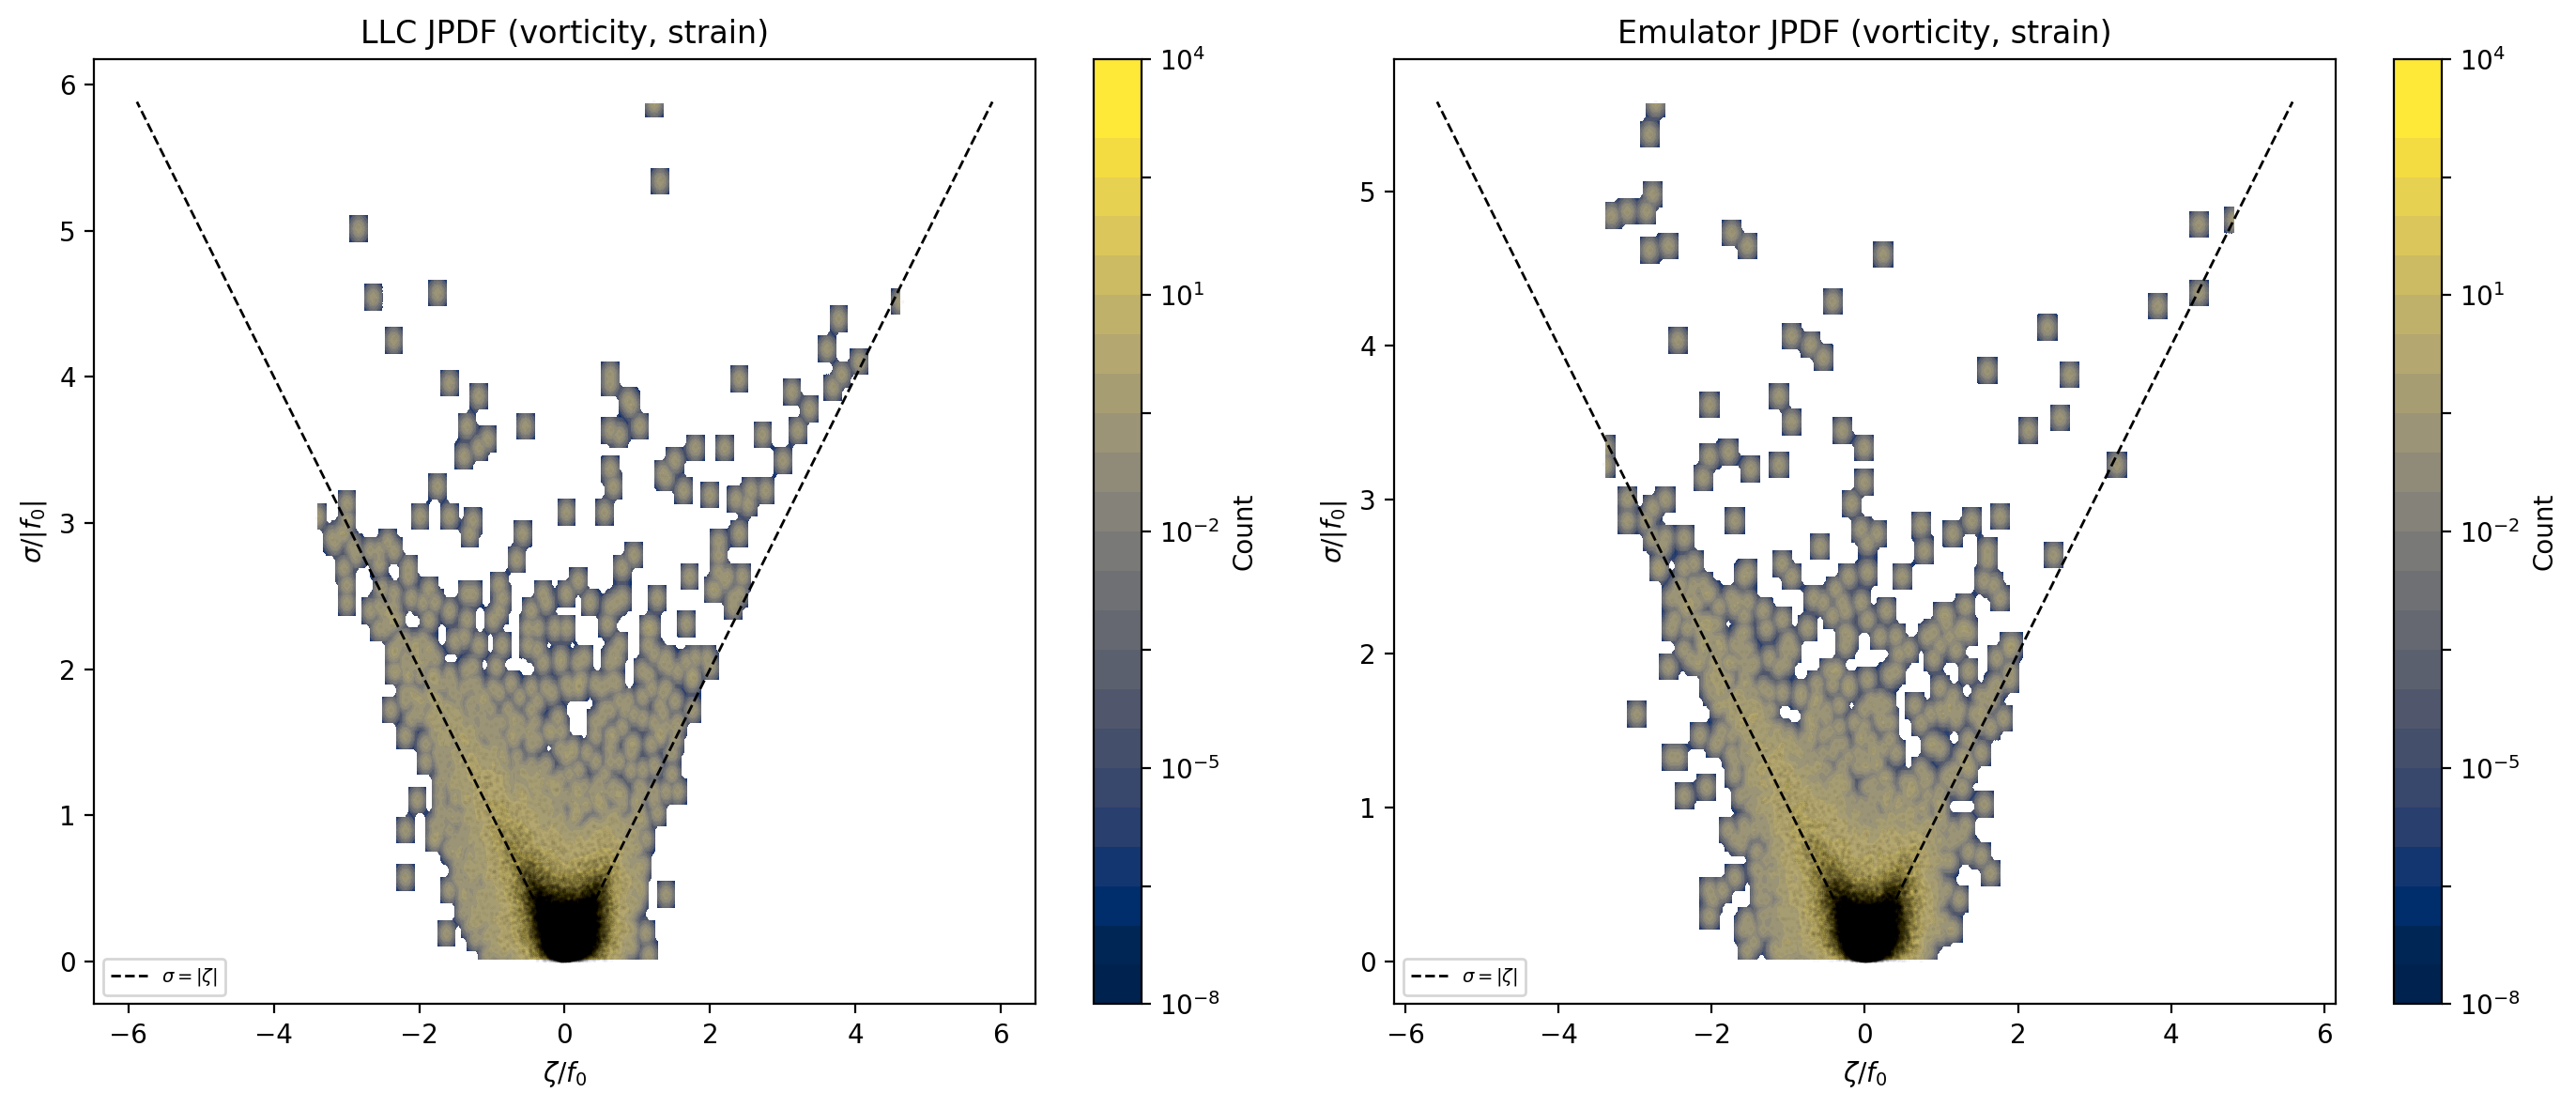

/tmp/ipykernel_514131/1266337324.py:100: UserWarning: No data for colormapping provided via 'c'. Parameters 'norm' will be ignored
  ax.scatter(v_sub, s_sub, s=0.1, alpha=0.05, color='k',


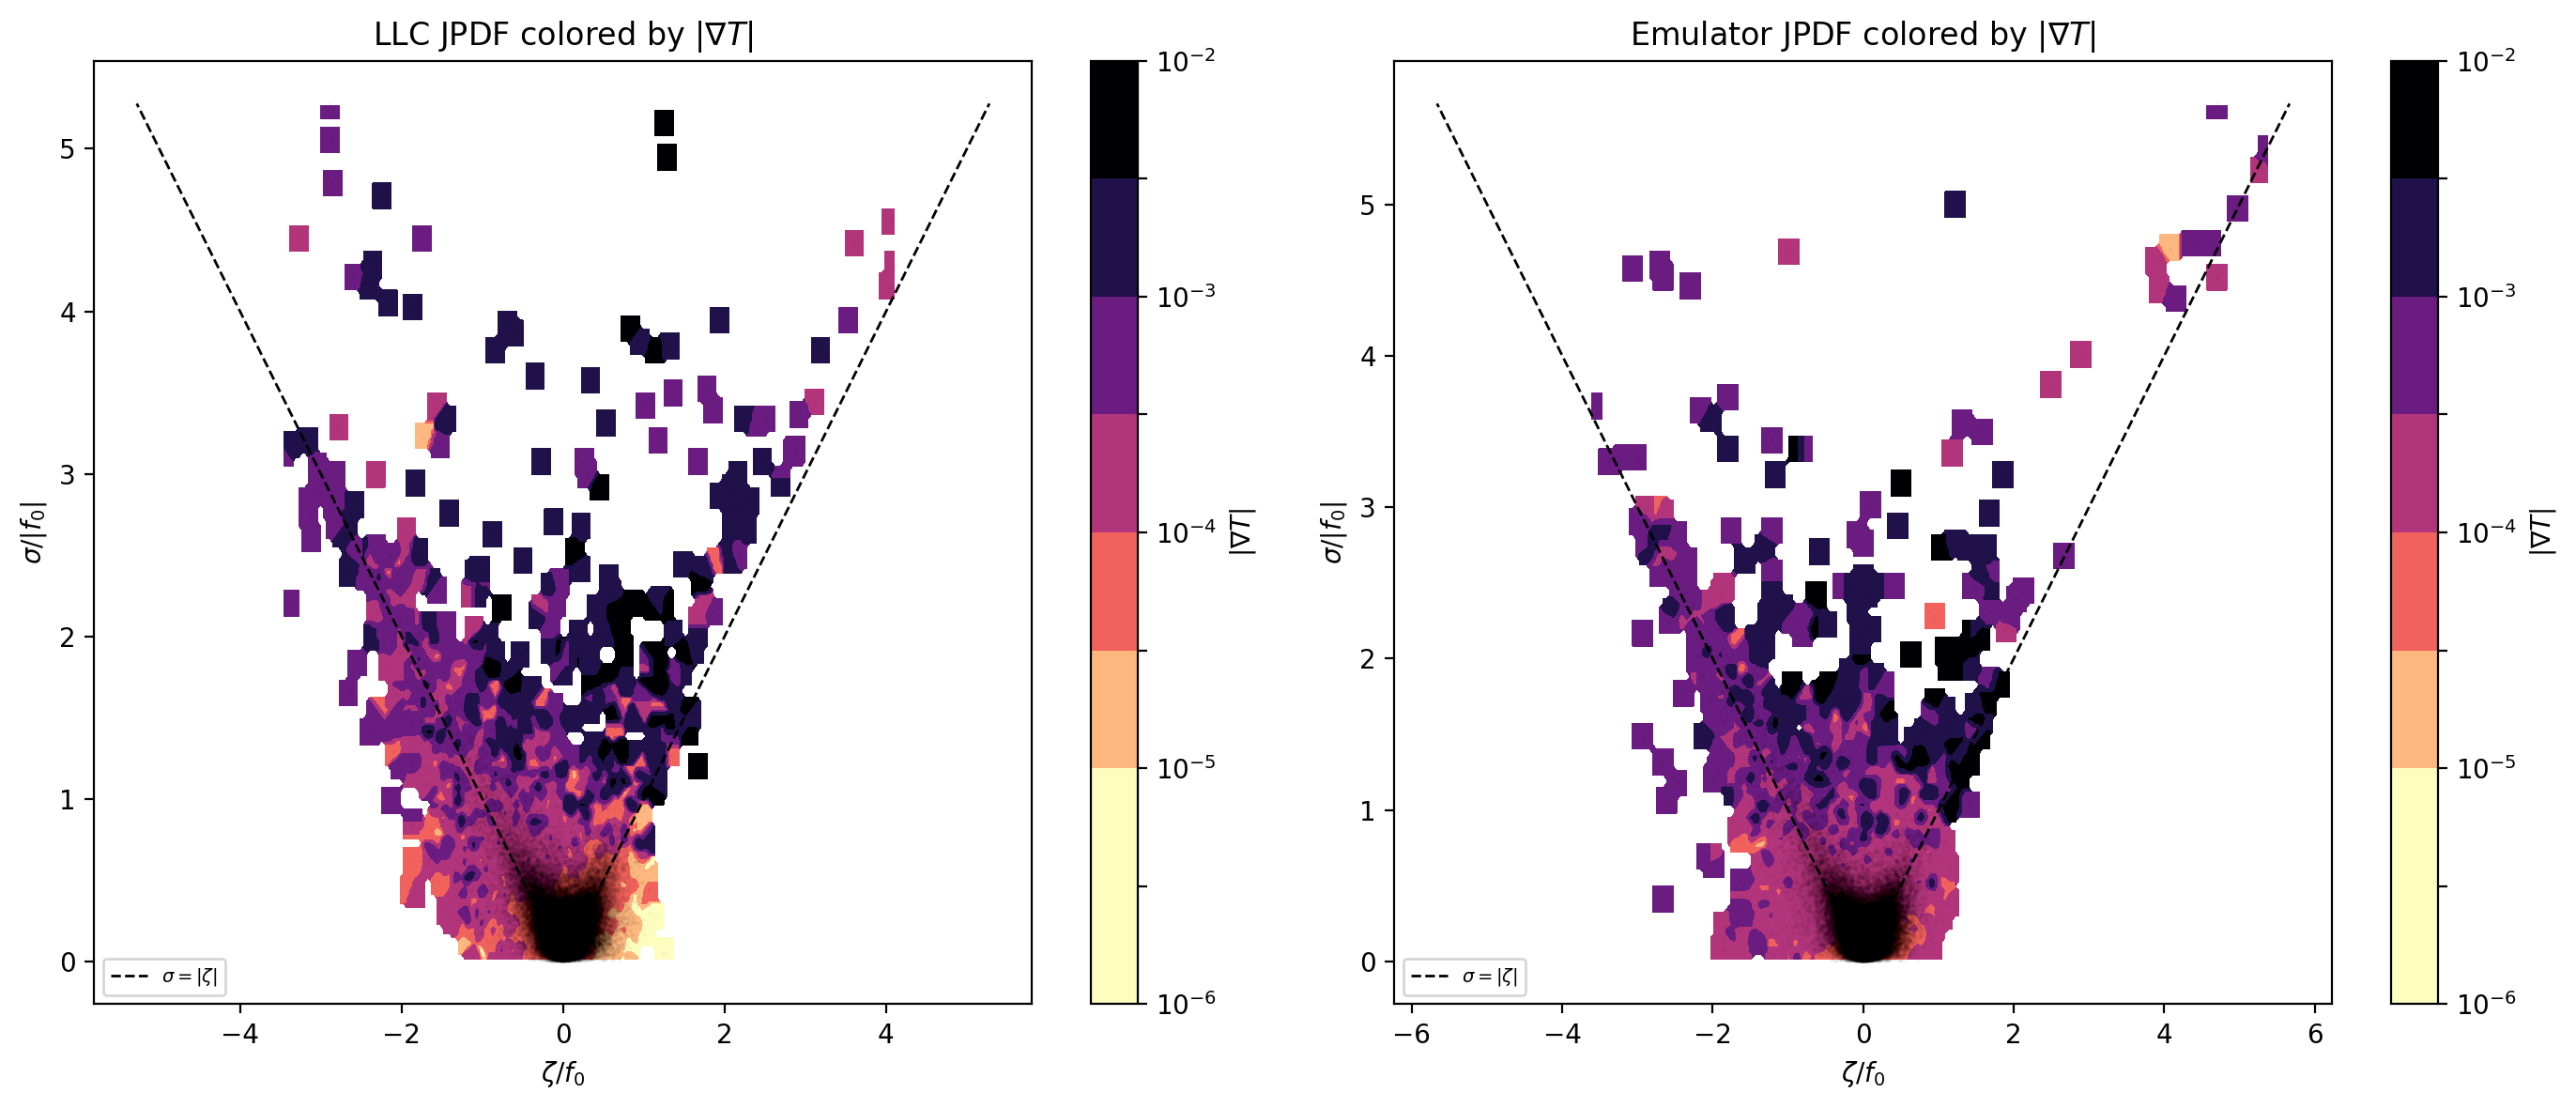

In [32]:
# ============================================================
# Figure 1: JPDF colored by log point density
# ============================================================

density_data = {}
for label, vort, strain in [('LLC', vort_hist_llc, strain_hist_llc),
                              ('Emulator', vort_hist_emulator, strain_hist_emulator)]:
    v = vort.flatten()
    s = strain.flatten()
    mask = ~(np.isnan(v) | np.isnan(s))
    v = v[mask]; s = s[mask]
    idx = np.random.choice(len(v), min(100000, len(v)), replace=False)
    v_sub = v[idx]; s_sub = s[idx]
    counts, xedges, yedges = np.histogram2d(v_sub, s_sub, bins=200)
    counts = gaussian_filter(counts, sigma=0.75)  # smooth
    counts = np.where(counts > 0, counts, np.nan)
    density_data[label] = (v_sub, s_sub, counts, xedges, yedges)

shared_vmin_d = min(np.nanmin(density_data['LLC'][2]), np.nanmin(density_data['Emulator'][2]))
shared_vmax_d = max(np.nanmax(density_data['LLC'][2]), np.nanmax(density_data['Emulator'][2]))

log_min_d = np.floor(np.log10(shared_vmin_d))
log_max_d = np.ceil(np.log10(shared_vmax_d))
levels_d = 10 ** np.arange(log_min_d, log_max_d + 0.5, 0.5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=200)

for ax, label in [(ax1, 'LLC'), (ax2, 'Emulator')]:
    v_sub, s_sub, counts, xedges, yedges = density_data[label]
    
    xc = (xedges[:-1] + xedges[1:]) / 2
    yc = (yedges[:-1] + yedges[1:]) / 2
    
    cf = ax.contourf(xc, yc, counts.T, levels=levels_d, 
                     cmap='cividis', norm=LogNorm(vmin=shared_vmin_d, vmax=shared_vmax_d))
    ax.scatter(v_sub, s_sub, s=0.1, alpha=0.05, c='k')
    
    lim = max(np.abs(v_sub).max(), s_sub.max())
    ax.plot([0, lim], [0, lim], 'k--', linewidth=1, label=r'$\sigma = |\zeta|$')
    ax.plot([0, -lim], [0, lim], 'k--', linewidth=1)
    
    cbar = plt.colorbar(cf, ax=ax, label='Count')
    cbar.ax.yaxis.set_major_formatter(LogFormatterMathtext())
    ax.set_xlabel(r'$\zeta / f_0$')
    ax.set_ylabel(r'$\sigma / |f_0|$')
    ax.set_title(f'{label} JPDF (vorticity, strain)')
    ax.legend(fontsize=7)

plt.tight_layout()
#plt.savefig('figs/JPDF_vort_strain_density.png')
plt.show()

# ============================================================
# Figure 2: JPDF colored by grad_T
# ============================================================

gradT_data = {}
for label, vort, strain, grad_T in [('LLC', vort_hist_llc, strain_hist_llc, grad_T_hist_llc),
                                      ('Emulator', vort_hist_emulator, strain_hist_emulator, grad_T_hist_emulator)]:
    v = vort.flatten()
    s = strain.flatten()
    g = grad_T.flatten()
    mask = ~(np.isnan(v) | np.isnan(s) | np.isnan(g)) & (g > 0)
    v = v[mask]; s = s[mask]; g = g[mask]
    idx = np.random.choice(len(v), min(100000, len(v)), replace=False)
    v_sub = v[idx]; s_sub = s[idx]; g_sub = g[idx]
    
    nbins = 200
    counts, xedges, yedges = np.histogram2d(v_sub, s_sub, bins=nbins)
    g_sum, _, _ = np.histogram2d(v_sub, s_sub, bins=[xedges, yedges], weights=g_sub)
    
    # Smooth both before dividing
    counts_smooth = gaussian_filter(counts, sigma=0.75)
    g_sum_smooth = gaussian_filter(g_sum, sigma=0.75)
    
    g_mean = np.full_like(counts_smooth, np.nan)
    valid = counts_smooth > 0
    g_mean[valid] = g_sum_smooth[valid] / counts_smooth[valid]
    g_mean = np.where(g_mean > 0, g_mean, np.nan)
    
    gradT_data[label] = (v_sub, s_sub, g_sub, g_mean, xedges, yedges)

shared_vmin_g = min(np.nanpercentile(gradT_data['LLC'][3], 1), np.nanpercentile(gradT_data['Emulator'][3], 1))
shared_vmax_g = max(np.nanpercentile(gradT_data['LLC'][3], 99), np.nanpercentile(gradT_data['Emulator'][3], 99))

log_min_g = np.floor(np.log10(shared_vmin_g))
log_max_g = np.ceil(np.log10(shared_vmax_g))
levels_g = 10 ** np.arange(log_min_g, log_max_g + 0.5, 0.5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=200)

for ax, label in [(ax1, 'LLC'), (ax2, 'Emulator')]:
    v_sub, s_sub, g_sub, g_mean, xedges, yedges = gradT_data[label]
    
    xc = (xedges[:-1] + xedges[1:]) / 2
    yc = (yedges[:-1] + yedges[1:]) / 2
    
    cf = ax.contourf(xc, yc, g_mean.T, levels=levels_g, 
                     cmap='magma_r', norm=LogNorm(vmin=shared_vmin_g, vmax=shared_vmax_g))
    ax.scatter(v_sub, s_sub, s=0.1, alpha=0.05, color='k',
               norm=LogNorm(vmin=shared_vmin_g, vmax=shared_vmax_g))
    
    lim = max(np.abs(v_sub).max(), s_sub.max())
    ax.plot([0, lim], [0, lim], 'k--', linewidth=1, label=r'$\sigma = |\zeta|$')
    ax.plot([0, -lim], [0, lim], 'k--', linewidth=1)
    
    cbar = plt.colorbar(cf, ax=ax, label=r'$|\nabla T|$')
    cbar.ax.yaxis.set_major_formatter(LogFormatterMathtext())
    ax.set_xlabel(r'$\zeta / f_0$')
    ax.set_ylabel(r'$\sigma / |f_0|$')
    ax.set_title(f'{label} JPDF colored by ' + r'$|\nabla T|$')
    ax.legend(fontsize=7)

plt.tight_layout()
#plt.savefig('figs/JPDF_vort_strain_gradT.png')
plt.show()

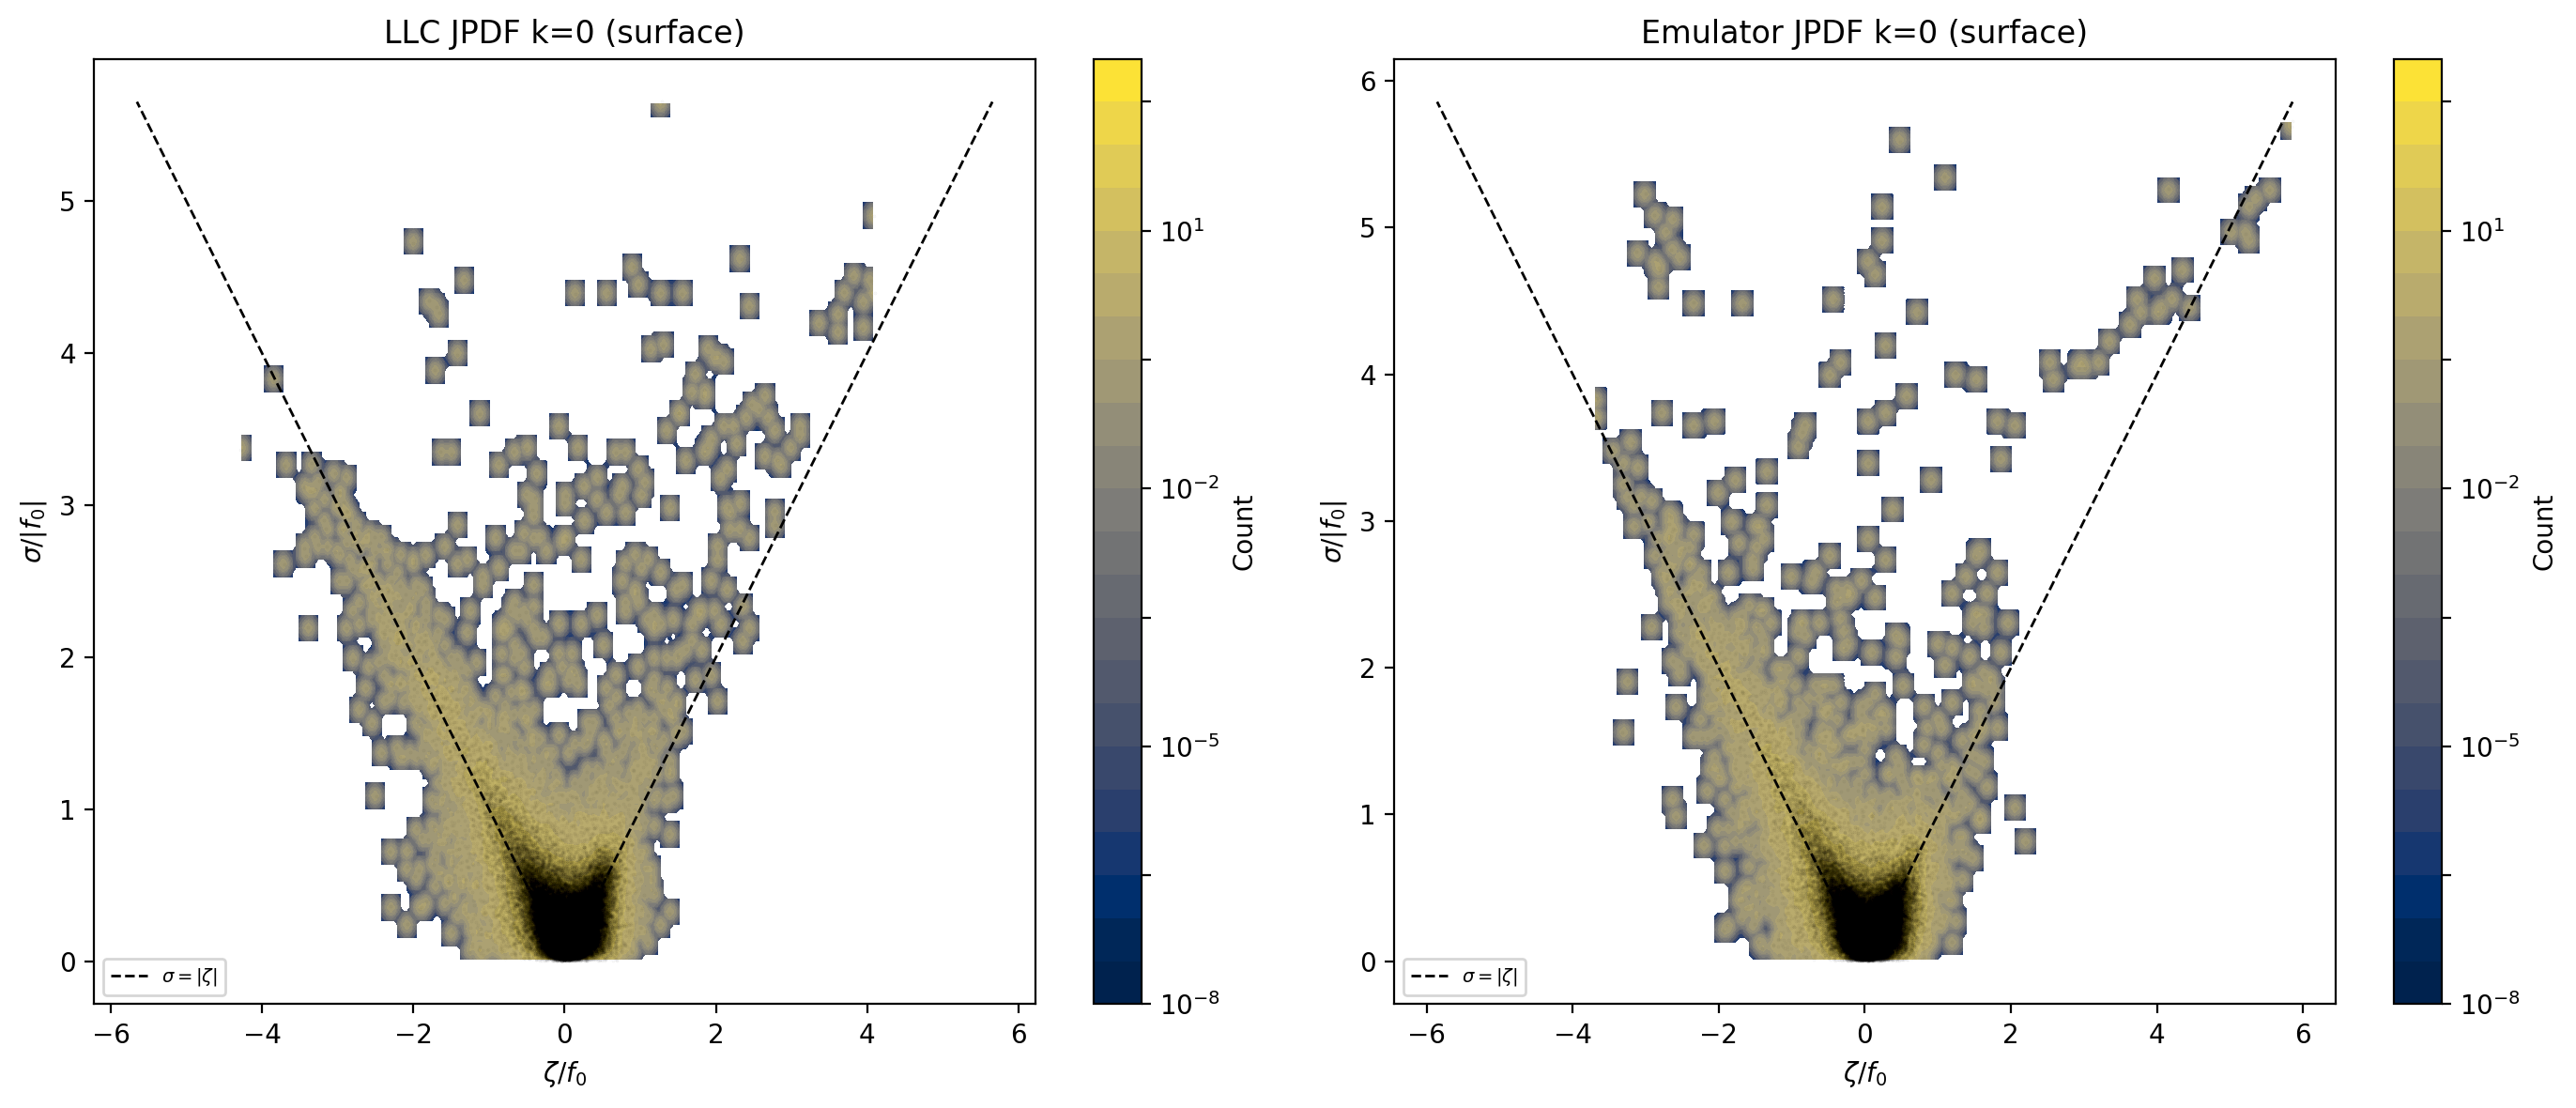

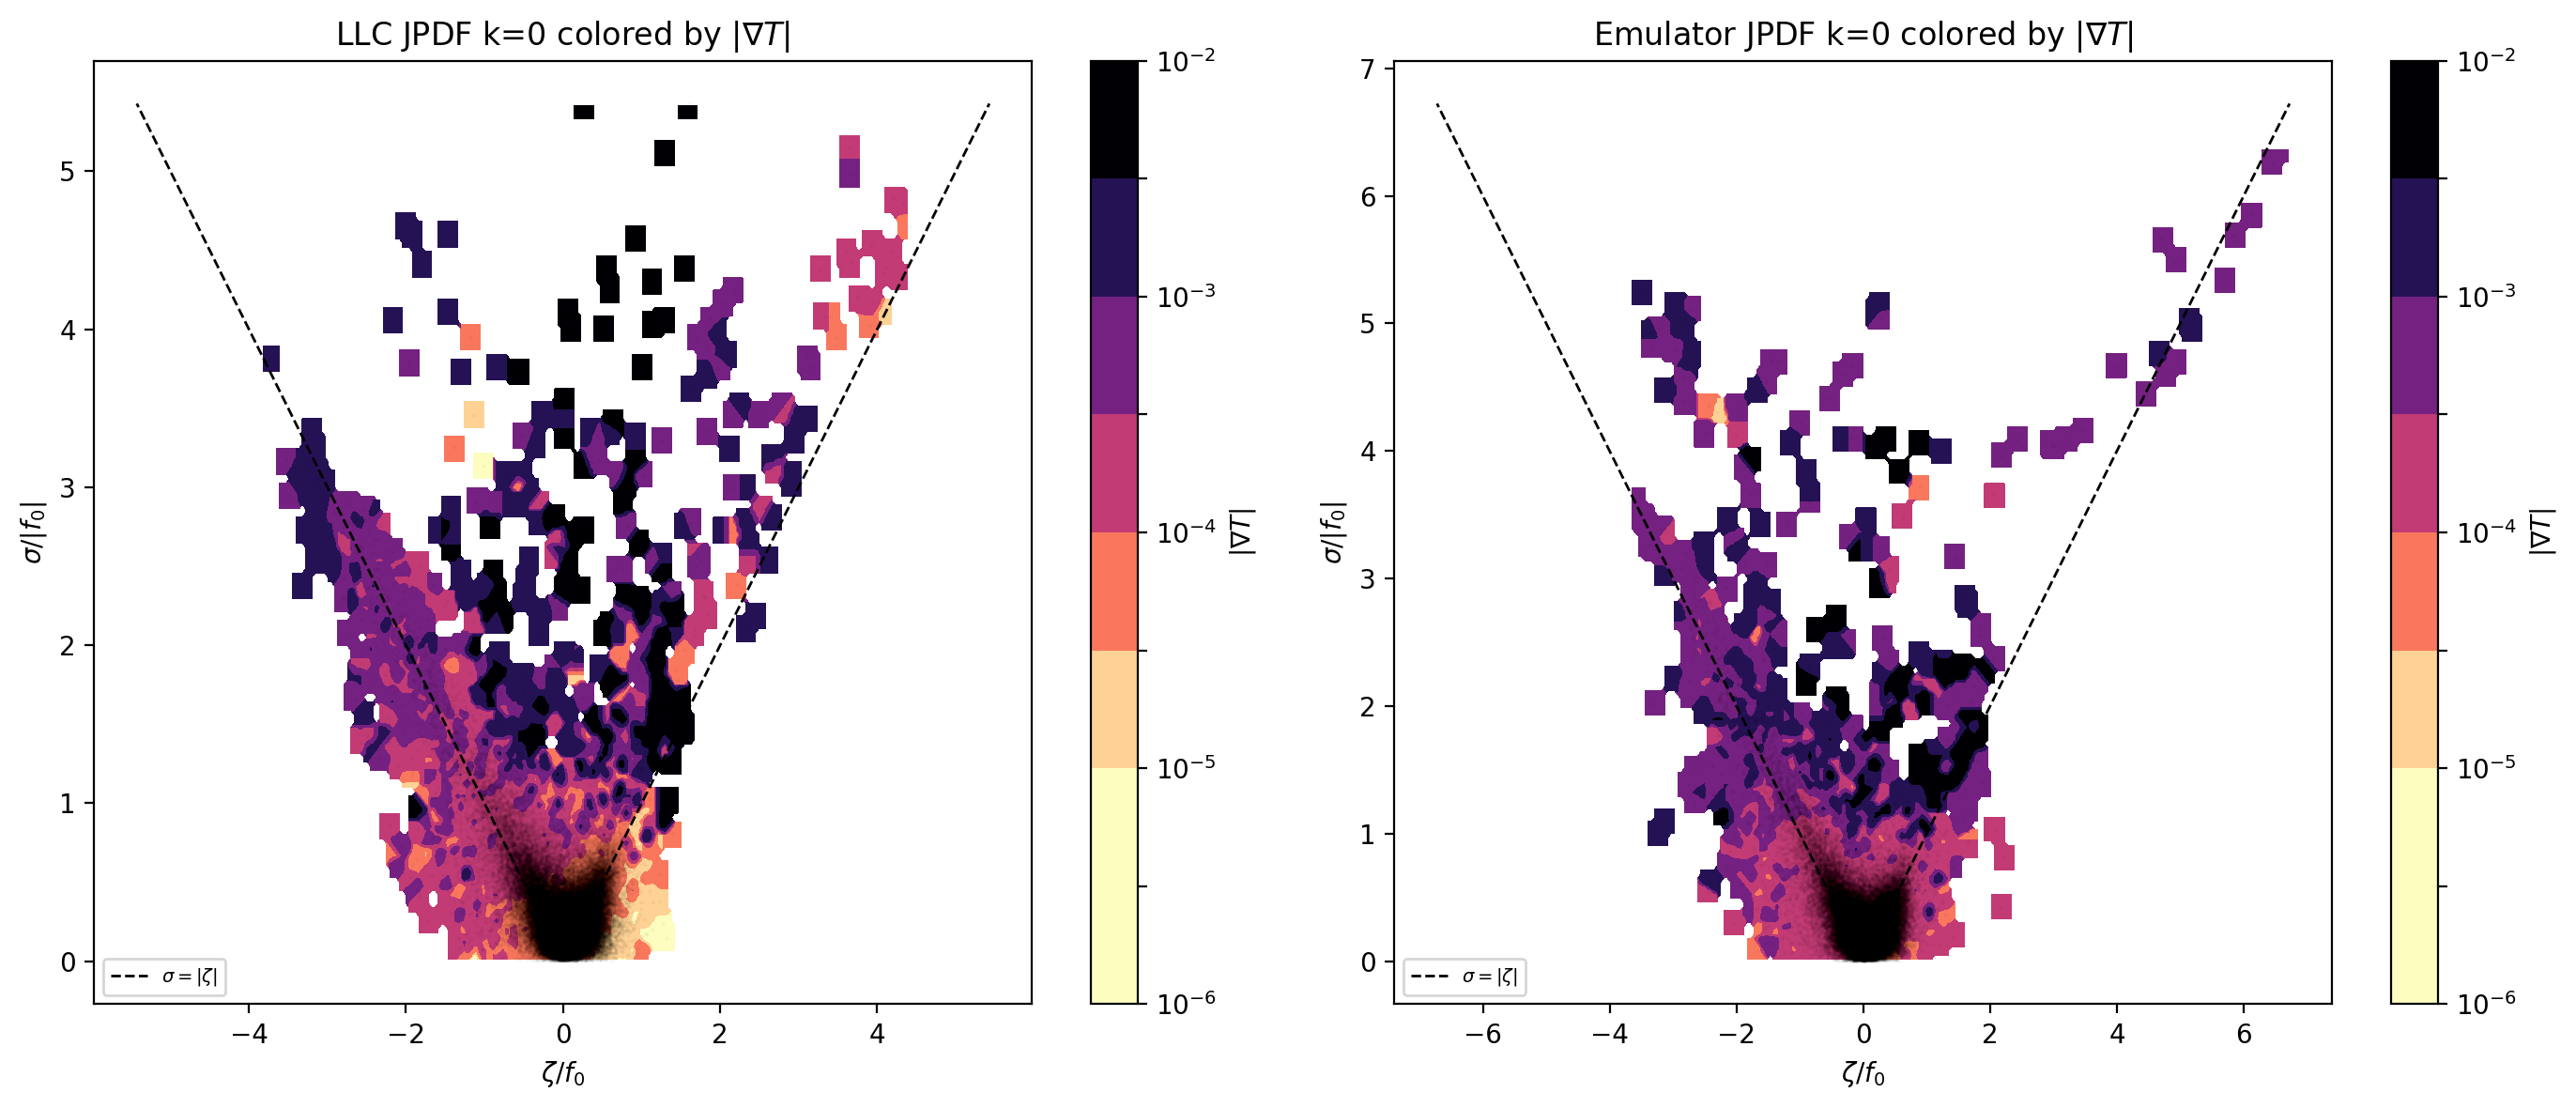

In [33]:
# ============================================================
# Surface (k=0) JPDF
# ============================================================
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogFormatterMathtext
from scipy.ndimage import gaussian_filter

# --- Figure 1: Density ---
density_data = {}
for label, vort, strain in [('LLC', vort_hist_llc, strain_hist_llc),
                              ('Emulator', vort_hist_emulator, strain_hist_emulator)]:
    v = vort[0]  # k=0
    s = strain[0]
    mask = ~(np.isnan(v) | np.isnan(s))
    v = v[mask]; s = s[mask]
    idx = np.random.choice(len(v), min(100000, len(v)), replace=False)
    v_sub = v[idx]; s_sub = s[idx]
    counts, xedges, yedges = np.histogram2d(v_sub, s_sub, bins=200)
    counts = gaussian_filter(counts, sigma=0.75)
    counts = np.where(counts > 0, counts, np.nan)
    density_data[label] = (v_sub, s_sub, counts, xedges, yedges)

shared_vmin_d = min(np.nanmin(density_data['LLC'][2]), np.nanmin(density_data['Emulator'][2]))
shared_vmax_d = max(np.nanmax(density_data['LLC'][2]), np.nanmax(density_data['Emulator'][2]))
log_min_d = np.floor(np.log10(shared_vmin_d))
log_max_d = np.ceil(np.log10(shared_vmax_d))
levels_d = 10 ** np.arange(log_min_d, log_max_d + 0.5, 0.5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=200)
for ax, label in [(ax1, 'LLC'), (ax2, 'Emulator')]:
    v_sub, s_sub, counts, xedges, yedges = density_data[label]
    xc = (xedges[:-1] + xedges[1:]) / 2
    yc = (yedges[:-1] + yedges[1:]) / 2
    cf = ax.contourf(xc, yc, counts.T, levels=levels_d,
                     cmap='cividis', norm=LogNorm(vmin=shared_vmin_d, vmax=shared_vmax_d))
    ax.scatter(v_sub, s_sub, s=0.1, alpha=0.05, c='k')
    lim = max(np.abs(v_sub).max(), s_sub.max())
    ax.plot([0, lim], [0, lim], 'k--', linewidth=1, label=r'$\sigma = |\zeta|$')
    ax.plot([0, -lim], [0, lim], 'k--', linewidth=1)
    cbar = plt.colorbar(cf, ax=ax, label='Count')
    cbar.ax.yaxis.set_major_formatter(LogFormatterMathtext())
    ax.set_xlabel(r'$\zeta / f_0$'); ax.set_ylabel(r'$\sigma / |f_0|$')
    ax.set_title(f'{label} JPDF k=0 (surface)')
    ax.legend(fontsize=7)
plt.tight_layout()
#plt.savefig('figs/JPDF_vort_strain_density_k0.png')
plt.show()

# --- Figure 2: grad_T ---
gradT_data = {}
for label, vort, strain, grad_T in [('LLC', vort_hist_llc, strain_hist_llc, grad_T_hist_llc),
                                      ('Emulator', vort_hist_emulator, strain_hist_emulator, grad_T_hist_emulator)]:
    v = vort[0]; s = strain[0]; g = grad_T[0]
    mask = ~(np.isnan(v) | np.isnan(s) | np.isnan(g)) & (g > 0)
    v = v[mask]; s = s[mask]; g = g[mask]
    idx = np.random.choice(len(v), min(100000, len(v)), replace=False)
    v_sub = v[idx]; s_sub = s[idx]; g_sub = g[idx]
    counts, xedges, yedges = np.histogram2d(v_sub, s_sub, bins=200)
    g_sum, _, _ = np.histogram2d(v_sub, s_sub, bins=[xedges, yedges], weights=g_sub)
    counts_smooth = gaussian_filter(counts, sigma=0.75)
    g_sum_smooth = gaussian_filter(g_sum, sigma=0.75)
    g_mean = np.full_like(counts_smooth, np.nan)
    valid = counts_smooth > 0
    g_mean[valid] = g_sum_smooth[valid] / counts_smooth[valid]
    g_mean = np.where(g_mean > 0, g_mean, np.nan)
    gradT_data[label] = (v_sub, s_sub, g_sub, g_mean, xedges, yedges)

shared_vmin_g = min(np.nanpercentile(gradT_data['LLC'][3], 1), np.nanpercentile(gradT_data['Emulator'][3], 1))
shared_vmax_g = max(np.nanpercentile(gradT_data['LLC'][3], 99), np.nanpercentile(gradT_data['Emulator'][3], 99))
log_min_g = np.floor(np.log10(shared_vmin_g))
log_max_g = np.ceil(np.log10(shared_vmax_g))
levels_g = 10 ** np.arange(log_min_g, log_max_g + 0.5, 0.5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=200)
for ax, label in [(ax1, 'LLC'), (ax2, 'Emulator')]:
    v_sub, s_sub, g_sub, g_mean, xedges, yedges = gradT_data[label]
    xc = (xedges[:-1] + xedges[1:]) / 2
    yc = (yedges[:-1] + yedges[1:]) / 2
    cf = ax.contourf(xc, yc, g_mean.T, levels=levels_g,
                     cmap='magma_r', norm=LogNorm(vmin=shared_vmin_g, vmax=shared_vmax_g))
    ax.scatter(v_sub, s_sub, s=0.1, alpha=0.05, color='k')
    lim = max(np.abs(v_sub).max(), s_sub.max())
    ax.plot([0, lim], [0, lim], 'k--', linewidth=1, label=r'$\sigma = |\zeta|$')
    ax.plot([0, -lim], [0, lim], 'k--', linewidth=1)
    cbar = plt.colorbar(cf, ax=ax, label=r'$|\nabla T|$')
    cbar.ax.yaxis.set_major_formatter(LogFormatterMathtext())
    ax.set_xlabel(r'$\zeta / f_0$'); ax.set_ylabel(r'$\sigma / |f_0|$')
    ax.set_title(f'{label} JPDF k=0 colored by ' + r'$|\nabla T|$')
    ax.legend(fontsize=7)
plt.tight_layout()
#plt.savefig('figs/JPDF_vort_strain_gradT_k0.png')
plt.show()

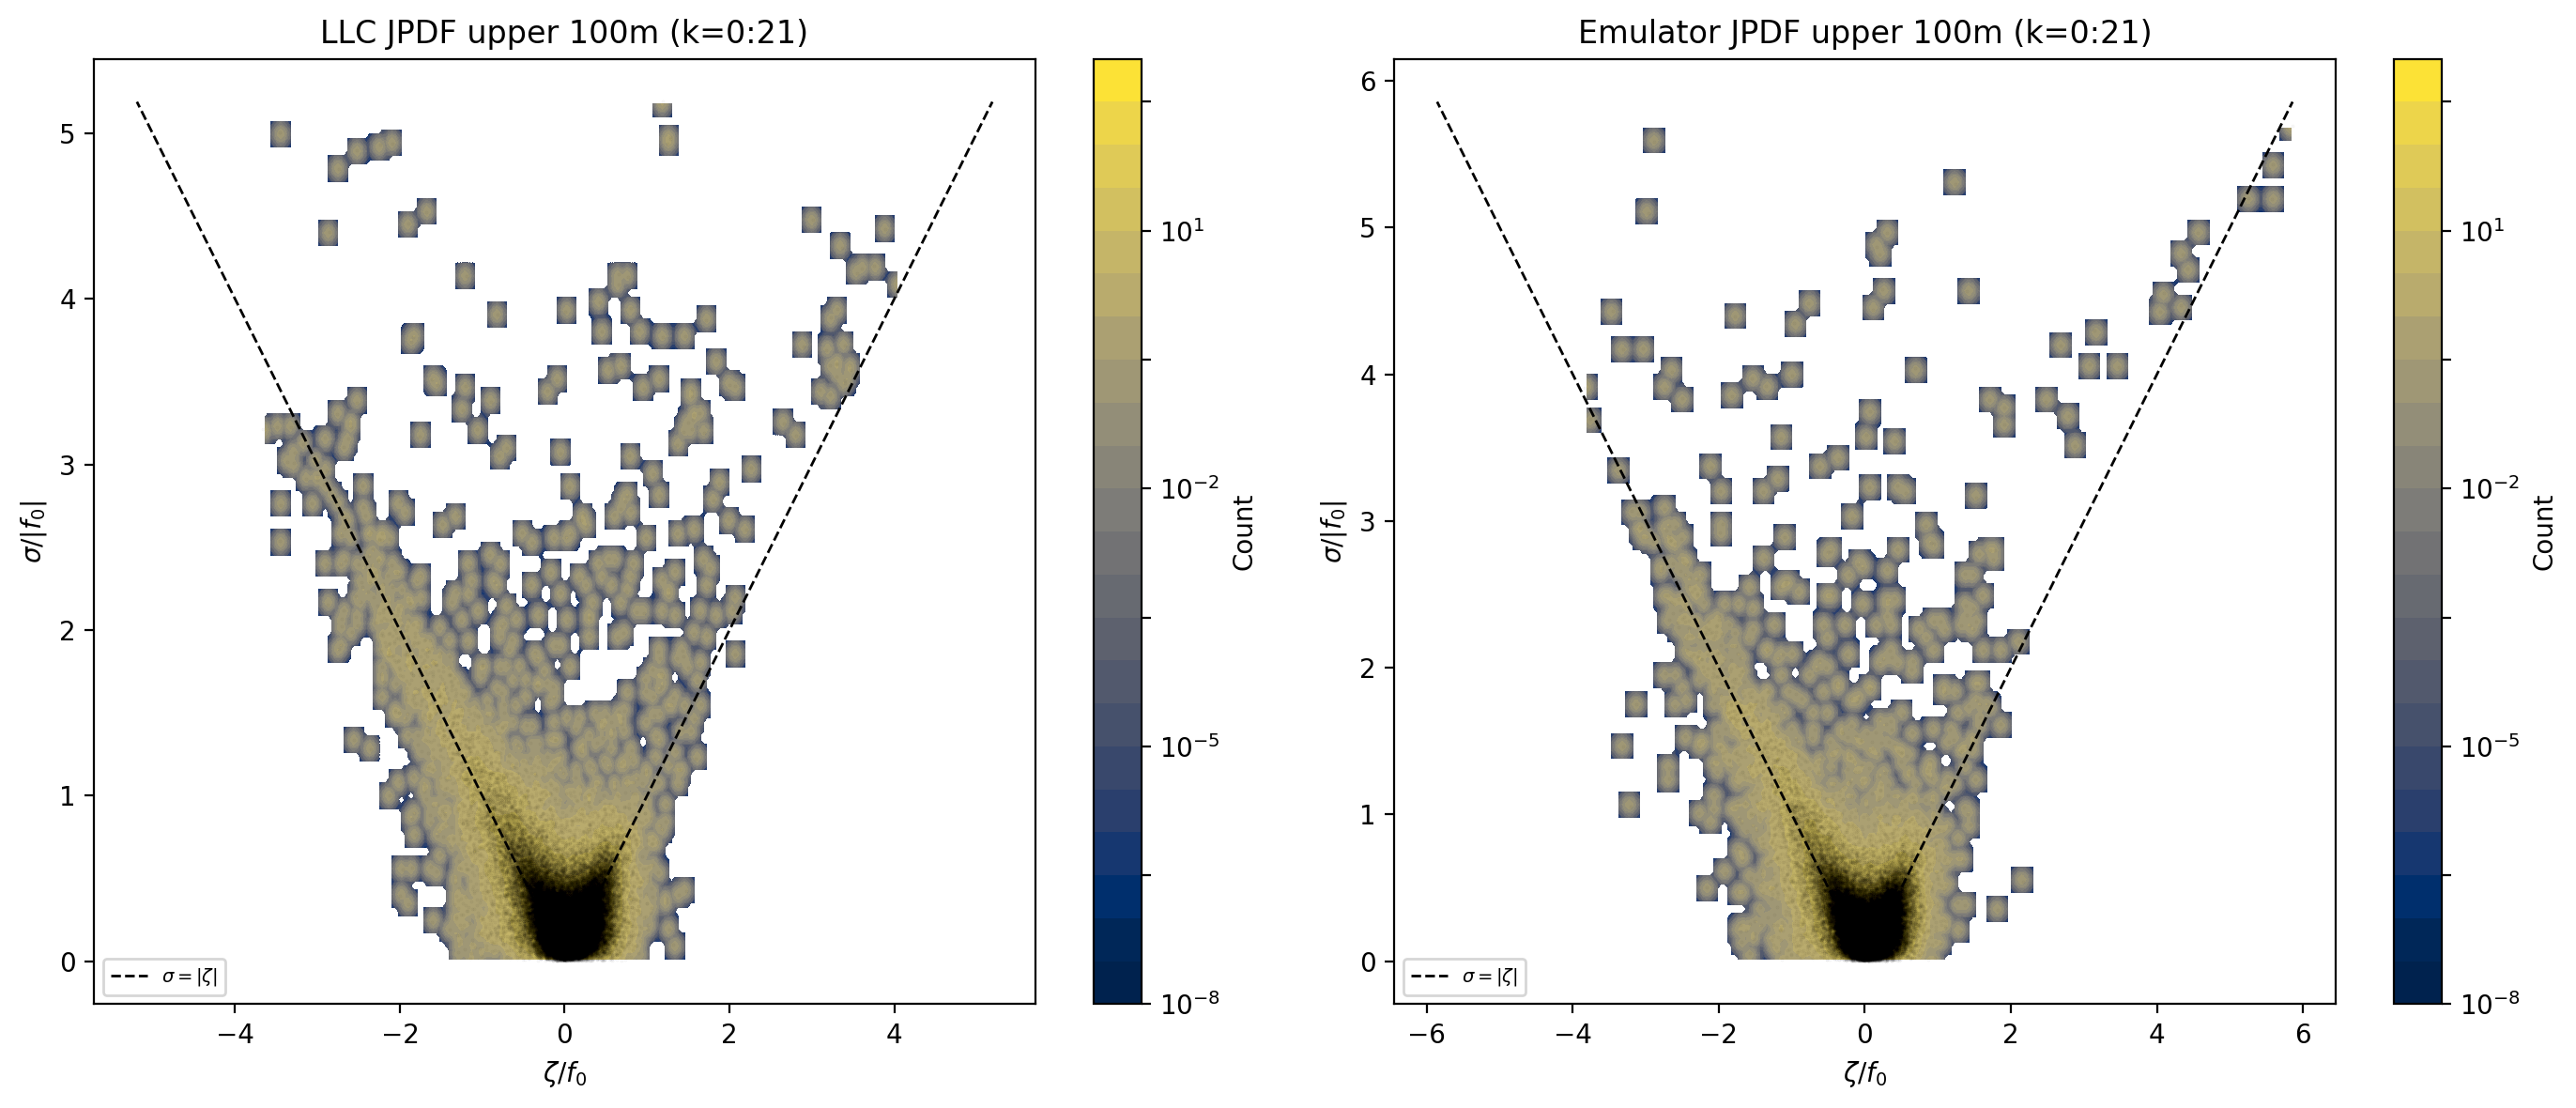

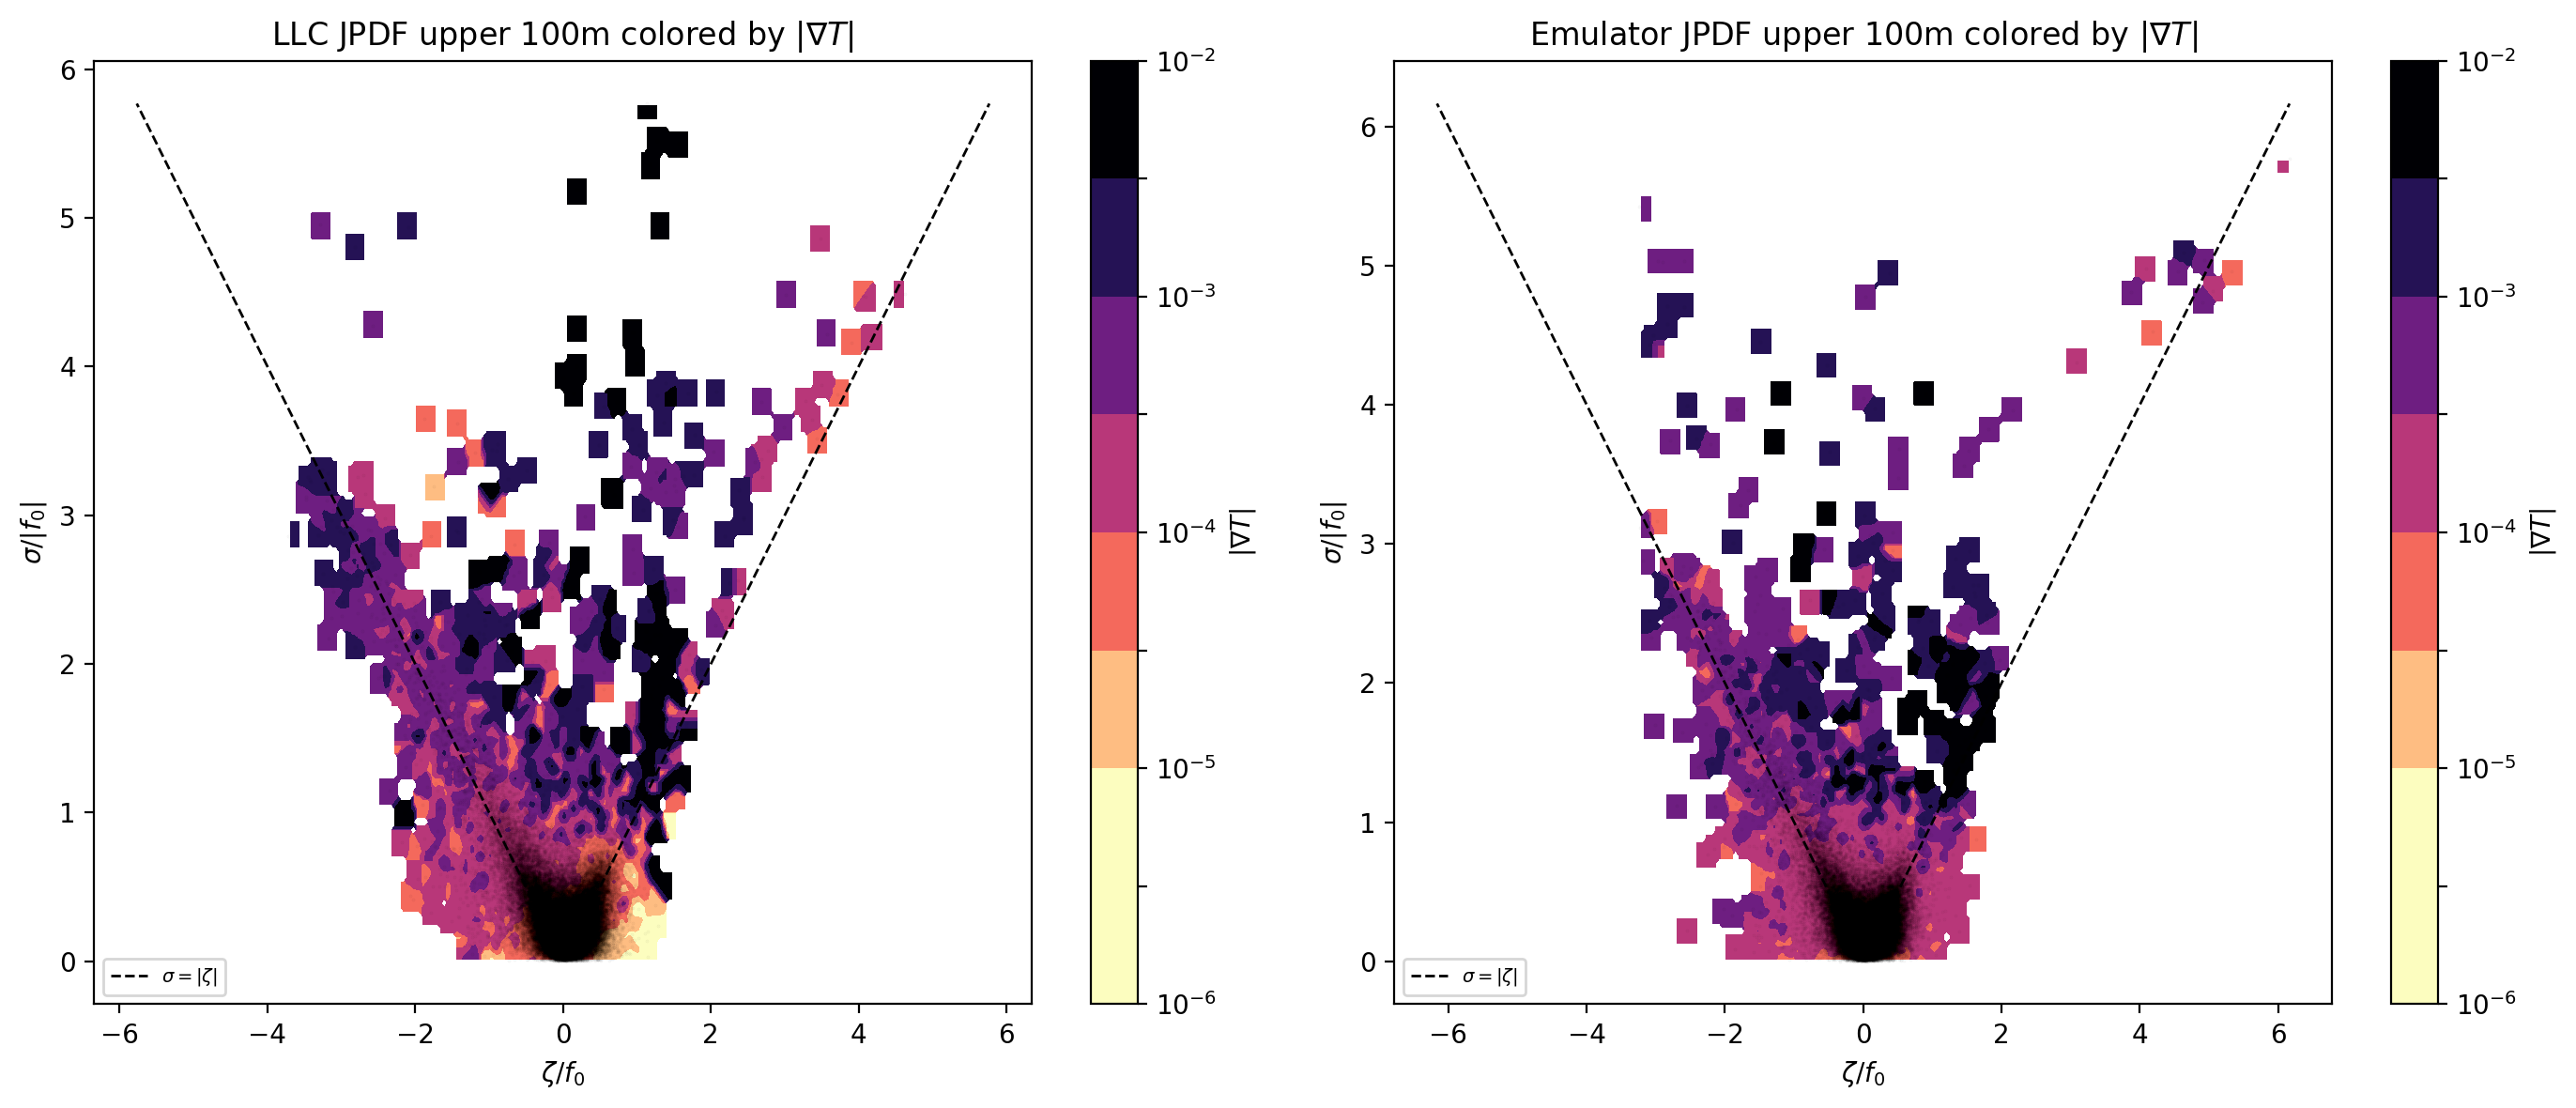

In [34]:
# ============================================================
# Blended upper 100m (k=0:21) JPDF
# ============================================================

# --- Figure 1: Density ---
density_data = {}
for label, vort, strain in [('LLC', vort_hist_llc, strain_hist_llc),
                              ('Emulator', vort_hist_emulator, strain_hist_emulator)]:
    v = vort[:21].flatten()  # k=0 to k=20
    s = strain[:21].flatten()
    mask = ~(np.isnan(v) | np.isnan(s))
    v = v[mask]; s = s[mask]
    idx = np.random.choice(len(v), min(100000, len(v)), replace=False)
    v_sub = v[idx]; s_sub = s[idx]
    counts, xedges, yedges = np.histogram2d(v_sub, s_sub, bins=200)
    counts = gaussian_filter(counts, sigma=0.75)
    counts = np.where(counts > 0, counts, np.nan)
    density_data[label] = (v_sub, s_sub, counts, xedges, yedges)

shared_vmin_d = min(np.nanmin(density_data['LLC'][2]), np.nanmin(density_data['Emulator'][2]))
shared_vmax_d = max(np.nanmax(density_data['LLC'][2]), np.nanmax(density_data['Emulator'][2]))
log_min_d = np.floor(np.log10(shared_vmin_d))
log_max_d = np.ceil(np.log10(shared_vmax_d))
levels_d = 10 ** np.arange(log_min_d, log_max_d + 0.5, 0.5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=200)
for ax, label in [(ax1, 'LLC'), (ax2, 'Emulator')]:
    v_sub, s_sub, counts, xedges, yedges = density_data[label]
    xc = (xedges[:-1] + xedges[1:]) / 2
    yc = (yedges[:-1] + yedges[1:]) / 2
    cf = ax.contourf(xc, yc, counts.T, levels=levels_d,
                     cmap='cividis', norm=LogNorm(vmin=shared_vmin_d, vmax=shared_vmax_d))
    ax.scatter(v_sub, s_sub, s=0.1, alpha=0.05, c='k')
    lim = max(np.abs(v_sub).max(), s_sub.max())
    ax.plot([0, lim], [0, lim], 'k--', linewidth=1, label=r'$\sigma = |\zeta|$')
    ax.plot([0, -lim], [0, lim], 'k--', linewidth=1)
    cbar = plt.colorbar(cf, ax=ax, label='Count')
    cbar.ax.yaxis.set_major_formatter(LogFormatterMathtext())
    ax.set_xlabel(r'$\zeta / f_0$'); ax.set_ylabel(r'$\sigma / |f_0|$')
    ax.set_title(f'{label} JPDF upper 100m (k=0:21)')
    ax.legend(fontsize=7)
plt.tight_layout()
#plt.savefig('figs/JPDF_vort_strain_density_upper100m.png')
plt.show()

# --- Figure 2: grad_T ---
gradT_data = {}
for label, vort, strain, grad_T in [('LLC', vort_hist_llc, strain_hist_llc, grad_T_hist_llc),
                                      ('Emulator', vort_hist_emulator, strain_hist_emulator, grad_T_hist_emulator)]:
    v = vort[:21].flatten(); s = strain[:21].flatten(); g = grad_T[:21].flatten()
    mask = ~(np.isnan(v) | np.isnan(s) | np.isnan(g)) & (g > 0)
    v = v[mask]; s = s[mask]; g = g[mask]
    idx = np.random.choice(len(v), min(100000, len(v)), replace=False)
    v_sub = v[idx]; s_sub = s[idx]; g_sub = g[idx]
    counts, xedges, yedges = np.histogram2d(v_sub, s_sub, bins=200)
    g_sum, _, _ = np.histogram2d(v_sub, s_sub, bins=[xedges, yedges], weights=g_sub)
    counts_smooth = gaussian_filter(counts, sigma=0.75)
    g_sum_smooth = gaussian_filter(g_sum, sigma=0.75)
    g_mean = np.full_like(counts_smooth, np.nan)
    valid = counts_smooth > 0
    g_mean[valid] = g_sum_smooth[valid] / counts_smooth[valid]
    g_mean = np.where(g_mean > 0, g_mean, np.nan)
    gradT_data[label] = (v_sub, s_sub, g_sub, g_mean, xedges, yedges)

shared_vmin_g = min(np.nanpercentile(gradT_data['LLC'][3], 1), np.nanpercentile(gradT_data['Emulator'][3], 1))
shared_vmax_g = max(np.nanpercentile(gradT_data['LLC'][3], 99), np.nanpercentile(gradT_data['Emulator'][3], 99))
log_min_g = np.floor(np.log10(shared_vmin_g))
log_max_g = np.ceil(np.log10(shared_vmax_g))
levels_g = 10 ** np.arange(log_min_g, log_max_g + 0.5, 0.5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), dpi=200)
for ax, label in [(ax1, 'LLC'), (ax2, 'Emulator')]:
    v_sub, s_sub, g_sub, g_mean, xedges, yedges = gradT_data[label]
    xc = (xedges[:-1] + xedges[1:]) / 2
    yc = (yedges[:-1] + yedges[1:]) / 2
    cf = ax.contourf(xc, yc, g_mean.T, levels=levels_g,
                     cmap='magma_r', norm=LogNorm(vmin=shared_vmin_g, vmax=shared_vmax_g))
    ax.scatter(v_sub, s_sub, s=0.1, alpha=0.05, color='k')
    lim = max(np.abs(v_sub).max(), s_sub.max())
    ax.plot([0, lim], [0, lim], 'k--', linewidth=1, label=r'$\sigma = |\zeta|$')
    ax.plot([0, -lim], [0, lim], 'k--', linewidth=1)
    cbar = plt.colorbar(cf, ax=ax, label=r'$|\nabla T|$')
    cbar.ax.yaxis.set_major_formatter(LogFormatterMathtext())
    ax.set_xlabel(r'$\zeta / f_0$'); ax.set_ylabel(r'$\sigma / |f_0|$')
    ax.set_title(f'{label} JPDF upper 100m colored by ' + r'$|\nabla T|$')
    ax.legend(fontsize=7)
plt.tight_layout()
#plt.savefig('figs/JPDF_vort_strain_gradT_upper100m.png')
plt.show()

In [36]:
# ============================================================
# All depths: 5 col x 10 row grid (k=0 to k=49)
# ============================================================
nrows = 10
ncols = 5
n_depths = nrows * ncols  # 50

# --- Pre-compute shared ranges across all depths for LLC ---

# Density shared range
all_counts_min = np.inf
all_counts_max = -np.inf
all_g_vals = []

for k in range(n_depths):
    for vort, strain in [(vort_hist_llc, strain_hist_llc)]:
        v = vort[k]; s = strain[k]
        mask = ~(np.isnan(v) | np.isnan(s))
        v = v[mask]; s = s[mask]
        idx = np.random.choice(len(v), min(50000, len(v)), replace=False)
        counts, _, _ = np.histogram2d(v[idx], s[idx], bins=100)
        counts = gaussian_filter(counts, sigma=0.75)
        counts = np.where(counts > 0, counts, np.nan)
        all_counts_min = min(all_counts_min, np.nanmin(counts))
        all_counts_max = max(all_counts_max, np.nanmax(counts))

log_min_d = np.floor(np.log10(all_counts_min))
log_max_d = np.ceil(np.log10(all_counts_max))
levels_d = 10 ** np.arange(log_min_d, log_max_d + 0.5, 0.5)

# --- Figure 1: Density per depth (LLC) ---
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 30), dpi=100)

for k in range(n_depths):
    row = k // ncols
    col = k % ncols
    ax = axes[row, col]
    
    v = vort_hist_llc[k]; s = strain_hist_llc[k]
    mask = ~(np.isnan(v) | np.isnan(s))
    v = v[mask]; s = s[mask]
    idx = np.random.choice(len(v), min(50000, len(v)), replace=False)
    v_sub = v[idx]; s_sub = s[idx]
    
    counts, xedges, yedges = np.histogram2d(v_sub, s_sub, bins=100)
    counts = gaussian_filter(counts, sigma=0.75)
    counts = np.where(counts > 0, counts, np.nan)
    
    xc = (xedges[:-1] + xedges[1:]) / 2
    yc = (yedges[:-1] + yedges[1:]) / 2
    
    cf = ax.contourf(xc, yc, counts.T, levels=levels_d,
                     cmap='cividis', norm=LogNorm(vmin=10**log_min_d, vmax=10**log_max_d))
    
    lim = max(np.abs(v_sub).max(), s_sub.max())
    ax.plot([0, lim], [0, lim], 'k--', linewidth=0.5)
    ax.plot([0, -lim], [0, lim], 'k--', linewidth=0.5)
    
    ax.set_title(f'k={k}', fontsize=7)
    ax.set_xticks([]); ax.set_yticks([])

sm = plt.cm.ScalarMappable(cmap='cividis', norm=LogNorm(vmin=10**log_min_d, vmax=10**log_max_d))
sm.set_array([])
cbar = plt.colorbar(sm, ax=axes.flatten(), label='Count', shrink=0.6)
cbar.ax.yaxis.set_major_formatter(LogFormatterMathtext())
plt.suptitle('LLC JPDF Density by Depth', fontsize=12)
#plt.tight_layout()
plt.savefig('figs/vorticity-strain-JPDFs/VS_density_alldepths_LLC.png')
#plt.show()
plt.close()

# --- Figure 1b: Density per depth (Emulator) ---
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 30), dpi=100)

for k in range(n_depths):
    row = k // ncols
    col = k % ncols
    ax = axes[row, col]
    
    v = vort_hist_emulator[k]; s = strain_hist_emulator[k]
    mask = ~(np.isnan(v) | np.isnan(s))
    v = v[mask]; s = s[mask]
    idx = np.random.choice(len(v), min(50000, len(v)), replace=False)
    v_sub = v[idx]; s_sub = s[idx]
    
    counts, xedges, yedges = np.histogram2d(v_sub, s_sub, bins=100)
    counts = gaussian_filter(counts, sigma=0.75)
    counts = np.where(counts > 0, counts, np.nan)
    
    xc = (xedges[:-1] + xedges[1:]) / 2
    yc = (yedges[:-1] + yedges[1:]) / 2
    
    cf = ax.contourf(xc, yc, counts.T, levels=levels_d,
                     cmap='cividis', norm=LogNorm(vmin=10**log_min_d, vmax=10**log_max_d))
    
    lim = max(np.abs(v_sub).max(), s_sub.max())
    ax.plot([0, lim], [0, lim], 'k--', linewidth=0.5)
    ax.plot([0, -lim], [0, lim], 'k--', linewidth=0.5)
    
    ax.set_title(f'k={k}', fontsize=7)
    ax.set_xticks([]); ax.set_yticks([])

sm = plt.cm.ScalarMappable(cmap='cividis', norm=LogNorm(vmin=10**log_min_d, vmax=10**log_max_d))
sm.set_array([])
cbar = plt.colorbar(sm, ax=axes.flatten(), label='Count', shrink=0.6)
cbar.ax.yaxis.set_major_formatter(LogFormatterMathtext())
plt.suptitle('Emulator JPDF Density by Depth', fontsize=12)
#plt.tight_layout()
plt.savefig('figs/vorticity-strain-JPDFs/VS_density_alldepths_emulator.png')
#plt.show()
plt.close()

# --- Pre-compute shared grad_T range ---
all_g_min = np.inf
all_g_max = -np.inf

for k in range(n_depths):
    for vort, strain, grad_T in [(vort_hist_llc, strain_hist_llc, grad_T_hist_llc)]:
        v = vort[k]; s = strain[k]; g = grad_T[k]
        mask = ~(np.isnan(v) | np.isnan(s) | np.isnan(g)) & (g > 0)
        v = v[mask]; s = s[mask]; g = g[mask]
        idx = np.random.choice(len(v), min(50000, len(v)), replace=False)
        counts, xedges, yedges = np.histogram2d(v[idx], s[idx], bins=100)
        g_sum, _, _ = np.histogram2d(v[idx], s[idx], bins=[xedges, yedges], weights=g[idx])
        counts_smooth = gaussian_filter(counts, sigma=0.75)
        g_sum_smooth = gaussian_filter(g_sum, sigma=0.75)
        g_mean = np.full_like(counts_smooth, np.nan)
        valid = counts_smooth > 0
        g_mean[valid] = g_sum_smooth[valid] / counts_smooth[valid]
        g_mean = np.where(g_mean > 0, g_mean, np.nan)
        if np.any(~np.isnan(g_mean)):
            all_g_min = min(all_g_min, np.nanpercentile(g_mean, 1))
            all_g_max = max(all_g_max, np.nanpercentile(g_mean, 99))

log_min_g = np.floor(np.log10(all_g_min))
log_max_g = np.ceil(np.log10(all_g_max))
levels_g = 10 ** np.arange(log_min_g, log_max_g + 0.5, 0.5)

# --- Figure 2: grad_T per depth (LLC) ---
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 30), dpi=100)

for k in range(n_depths):
    row = k // ncols
    col = k % ncols
    ax = axes[row, col]
    
    v = vort_hist_llc[k]; s = strain_hist_llc[k]; g = grad_T_hist_llc[k]
    mask = ~(np.isnan(v) | np.isnan(s) | np.isnan(g)) & (g > 0)
    v = v[mask]; s = s[mask]; g = g[mask]
    idx = np.random.choice(len(v), min(50000, len(v)), replace=False)
    v_sub = v[idx]; s_sub = s[idx]; g_sub = g[idx]
    
    counts, xedges, yedges = np.histogram2d(v_sub, s_sub, bins=100)
    g_sum, _, _ = np.histogram2d(v_sub, s_sub, bins=[xedges, yedges], weights=g_sub)
    counts_smooth = gaussian_filter(counts, sigma=0.75)
    g_sum_smooth = gaussian_filter(g_sum, sigma=0.75)
    g_mean = np.full_like(counts_smooth, np.nan)
    valid = counts_smooth > 0
    g_mean[valid] = g_sum_smooth[valid] / counts_smooth[valid]
    g_mean = np.where(g_mean > 0, g_mean, np.nan)
    
    xc = (xedges[:-1] + xedges[1:]) / 2
    yc = (yedges[:-1] + yedges[1:]) / 2
    
    cf = ax.contourf(xc, yc, g_mean.T, levels=levels_g,
                     cmap='magma_r', norm=LogNorm(vmin=10**log_min_g, vmax=10**log_max_g))
    
    lim = max(np.abs(v_sub).max(), s_sub.max())
    ax.plot([0, lim], [0, lim], 'k--', linewidth=0.5)
    ax.plot([0, -lim], [0, lim], 'k--', linewidth=0.5)
    
    ax.set_title(f'k={k}', fontsize=7)
    ax.set_xticks([]); ax.set_yticks([])

sm = plt.cm.ScalarMappable(cmap='magma_r', norm=LogNorm(vmin=10**log_min_g, vmax=10**log_max_g))
sm.set_array([])
cbar = plt.colorbar(sm, ax=axes.flatten(), label='|nabla T|', shrink=0.6)
cbar.ax.yaxis.set_major_formatter(LogFormatterMathtext())
#plt.suptitle(r'LLC JPDF colored by $$|\nabla T|$$ by Depth', fontsize=12)
#plt.tight_layout()
plt.savefig('figs/vorticity-strain-JPDFs/VS_gradT_alldepths_LLC.png')
#plt.show()
plt.close()

# --- Figure 2b: grad_T per depth (Emulator) ---
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 30), dpi=100)

for k in range(n_depths):
    row = k // ncols
    col = k % ncols
    ax = axes[row, col]
    
    v = vort_hist_emulator[k]; s = strain_hist_emulator[k]; g = grad_T_hist_emulator[k]
    mask = ~(np.isnan(v) | np.isnan(s) | np.isnan(g)) & (g > 0)
    v = v[mask]; s = s[mask]; g = g[mask]
    idx = np.random.choice(len(v), min(50000, len(v)), replace=False)
    v_sub = v[idx]; s_sub = s[idx]; g_sub = g[idx]
    
    counts, xedges, yedges = np.histogram2d(v_sub, s_sub, bins=100)
    g_sum, _, _ = np.histogram2d(v_sub, s_sub, bins=[xedges, yedges], weights=g_sub)
    counts_smooth = gaussian_filter(counts, sigma=0.75)
    g_sum_smooth = gaussian_filter(g_sum, sigma=0.75)
    g_mean = np.full_like(counts_smooth, np.nan)
    valid = counts_smooth > 0
    g_mean[valid] = g_sum_smooth[valid] / counts_smooth[valid]
    g_mean = np.where(g_mean > 0, g_mean, np.nan)
    
    xc = (xedges[:-1] + xedges[1:]) / 2
    yc = (yedges[:-1] + yedges[1:]) / 2
    
    cf = ax.contourf(xc, yc, g_mean.T, levels=levels_g,
                     cmap='magma_r', norm=LogNorm(vmin=10**log_min_g, vmax=10**log_max_g))
    
    lim = max(np.abs(v_sub).max(), s_sub.max())
    ax.plot([0, lim], [0, lim], 'k--', linewidth=0.5)
    ax.plot([0, -lim], [0, lim], 'k--', linewidth=0.5)
    
    ax.set_title(f'k={k}', fontsize=7)
    ax.set_xticks([]); ax.set_yticks([])

sm = plt.cm.ScalarMappable(cmap='magma_r', norm=LogNorm(vmin=10**log_min_g, vmax=10**log_max_g))
sm.set_array([])
cbar = plt.colorbar(sm, ax=axes.flatten(), label=r'$|\nabla T|$', shrink=0.6)
cbar.ax.yaxis.set_major_formatter(LogFormatterMathtext())
#plt.suptitle(r'Emulator JPDF colored by $|\nabla T|$ by Depth', fontsize=12)
#plt.tight_layout()
plt.savefig('figs/vorticity-strain-JPDFs/VS_gradT_alldepths_Emulator.png')
#plt.show()
plt.close()

FileNotFoundError: [Errno 2] No such file or directory: 'figs/vorticity-strain-JPDFs/VS_density_alldepths_LLC.png'

<Figure size 640x480 with 0 Axes>